In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./data/titanic_clean.csv")

In [3]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Valores nulos: {df.isnull().sum().sum()}")

df.head()

Filas: 891
Columnas: 8
Valores nulos: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [4]:
df.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
108,0,3,male,38.0,0,0,7.8958,S
230,1,1,female,35.0,1,0,83.4750,S
682,0,3,male,20.0,0,0,9.2250,S
761,0,3,male,41.0,0,0,7.1250,S


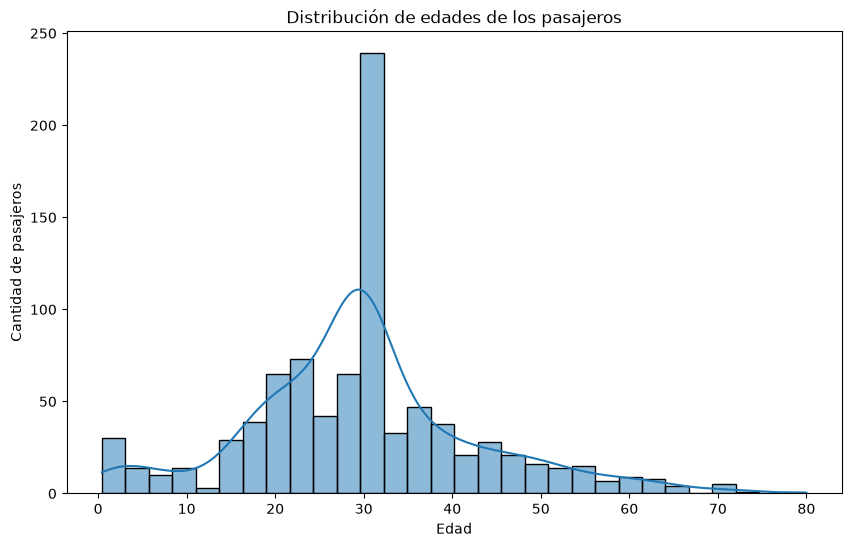

In [5]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True
)

plt.title("Distribución de edades de los pasajeros")
plt.xlabel("Edad")
plt.ylabel("Cantidad de pasajeros")
plt.show()

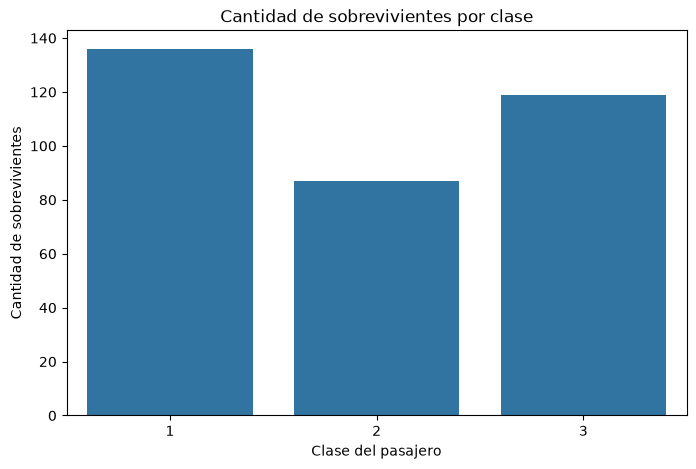

In [6]:
sobrevivientes = df[df["Survived"] == 1]

plt.figure(figsize=(8, 5))

sns.countplot(
    data=sobrevivientes,
    x="Pclass"
)

plt.title("Cantidad de sobrevivientes por clase")
plt.xlabel("Clase del pasajero")
plt.ylabel("Cantidad de sobrevivientes")
plt.show()

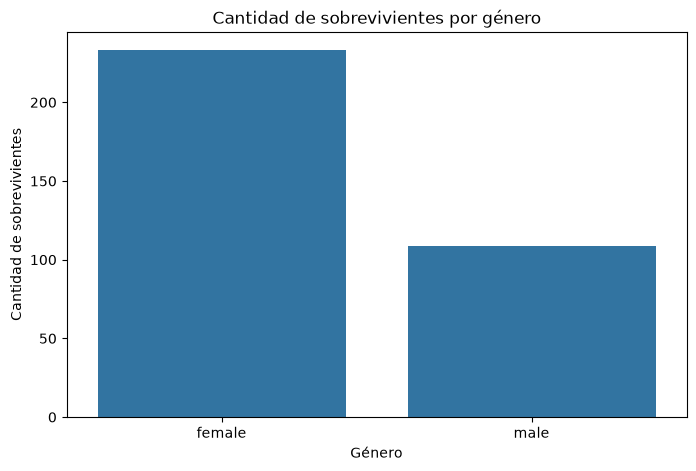

In [7]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=sobrevivientes,
    x="Sex"
)

plt.title("Cantidad de sobrevivientes por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de sobrevivientes")
plt.show()

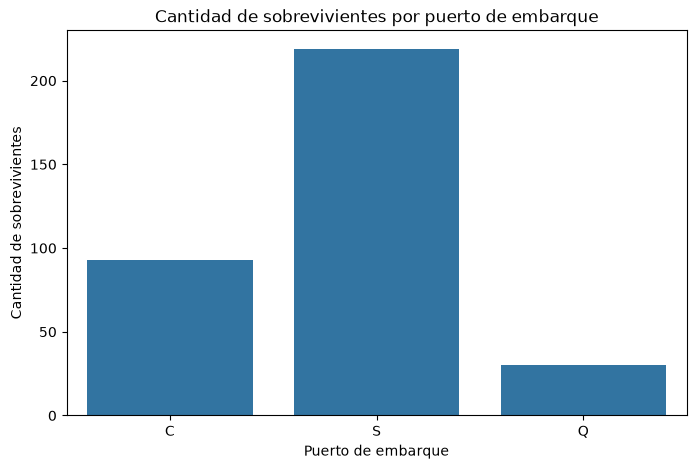

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=sobrevivientes,
    x="Embarked"
)

plt.title("Cantidad de sobrevivientes por puerto de embarque")
plt.xlabel("Puerto de embarque")
plt.ylabel("Cantidad de sobrevivientes")
plt.show()

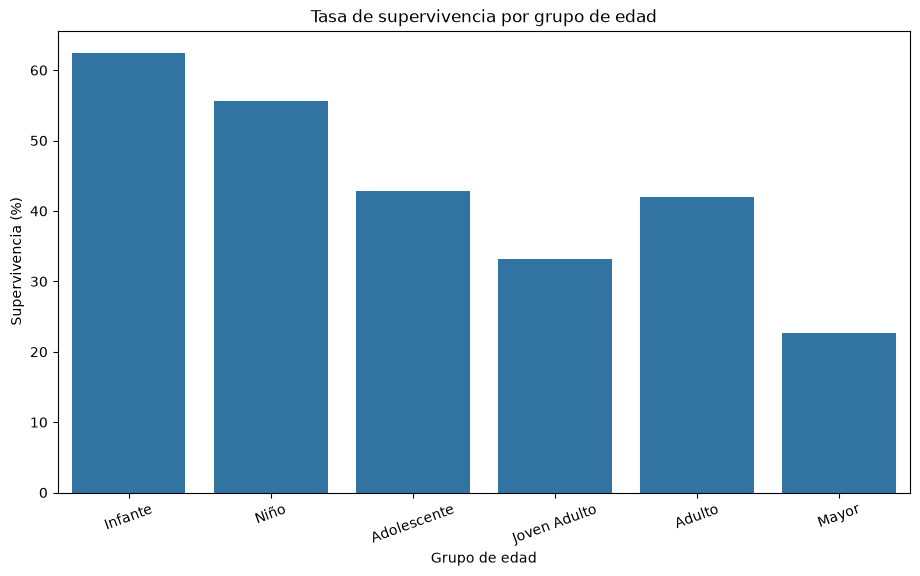

,GrupoEdad,Survived
0,Infante,62.500000
1,Niño,55.555556
2,Adolescente,42.857143
3,Joven Adulto,33.109620
4,Adulto,42.049470
5,Mayor,22.727273


In [9]:
intervalos = [0, 2, 12, 18, 30, 60, float("inf")]

categorias = [
    "Infante",
    "Niño",
    "Adolescente",
    "Joven Adulto",
    "Adulto",
    "Mayor"
]

df["GrupoEdad"] = pd.cut(
    df["Age"],
    bins=intervalos,
    labels=categorias,
    include_lowest=True
)

supervivencia_edad = (
    df.groupby("GrupoEdad", observed=False)["Survived"]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=supervivencia_edad,
    x="GrupoEdad",
    y="Survived"
)

plt.title("Tasa de supervivencia por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Supervivencia (%)")
plt.xticks(rotation=20)
plt.show()

supervivencia_edad

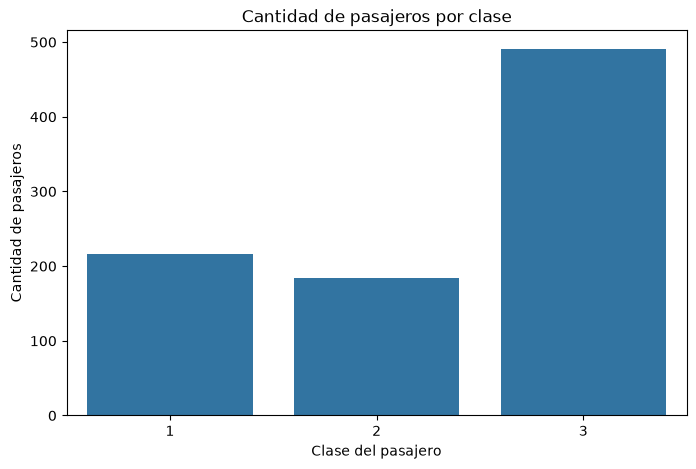

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Pclass"
)

plt.title("Cantidad de pasajeros por clase")
plt.xlabel("Clase del pasajero")
plt.ylabel("Cantidad de pasajeros")
plt.show()

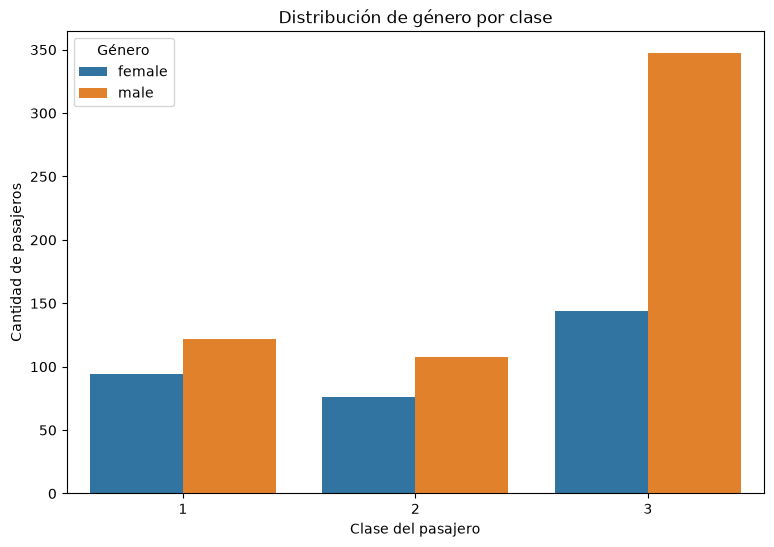

In [11]:
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Sex"
)

plt.title("Distribución de género por clase")
plt.xlabel("Clase del pasajero")
plt.ylabel("Cantidad de pasajeros")
plt.legend(title="Género")
plt.show()

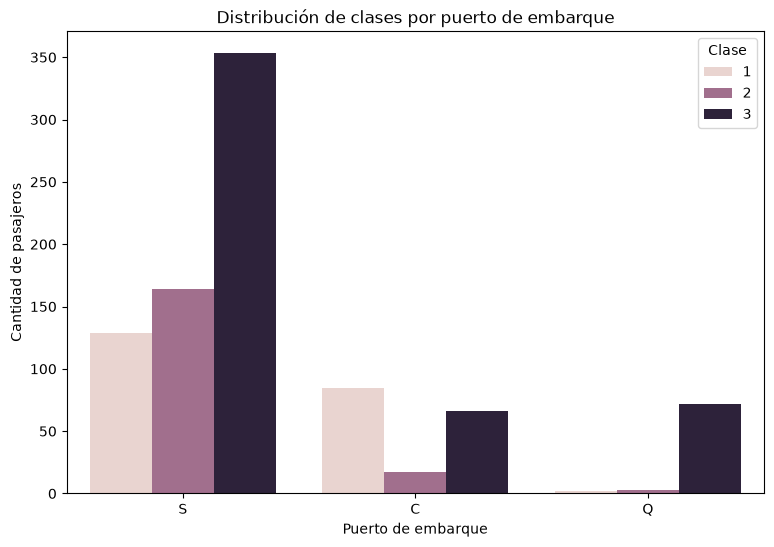

In [12]:
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="Embarked",
    hue="Pclass"
)

plt.title("Distribución de clases por puerto de embarque")
plt.xlabel("Puerto de embarque")
plt.ylabel("Cantidad de pasajeros")
plt.legend(title="Clase")
plt.show()

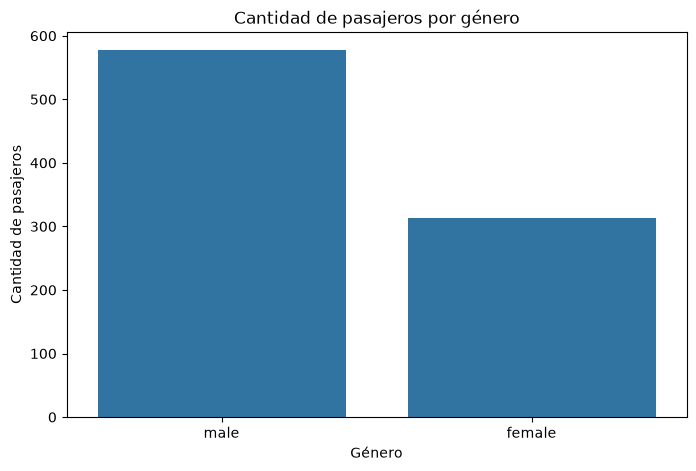

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Sex"
)

plt.title("Cantidad de pasajeros por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de pasajeros")
plt.show()

In [14]:
edad_minima = df["Age"].min()
edad_maxima = df["Age"].max()

print(f"Edad mínima: {edad_minima:.2f} años")
print(f"Edad máxima: {edad_maxima:.2f} años")

Edad mínima: 0.42 años
Edad máxima: 80.00 años


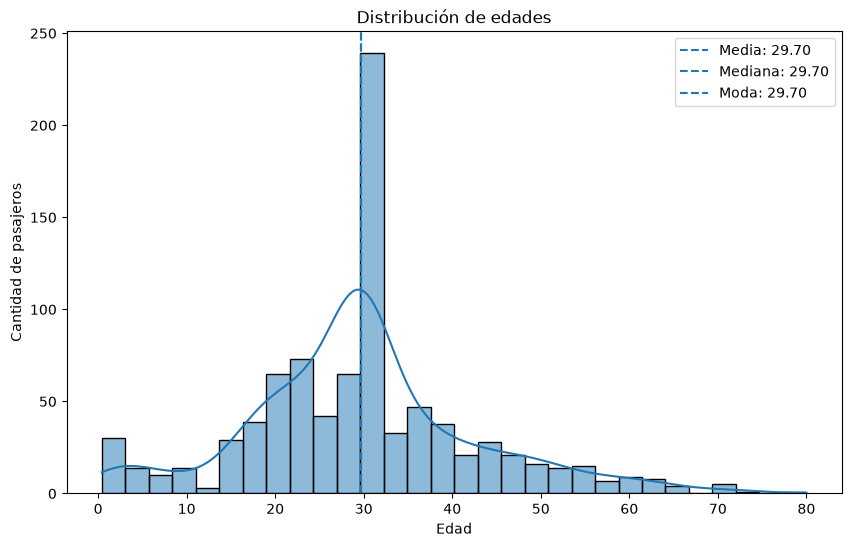

Media: 29.70
Mediana: 29.70
Moda: 29.70


In [15]:
media_edad = df["Age"].mean()
mediana_edad = df["Age"].median()
moda_edad = df["Age"].mode()[0]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True
)

plt.axvline(
    media_edad,
    linestyle="--",
    label=f"Media: {media_edad:.2f}"
)

plt.axvline(
    mediana_edad,
    linestyle="--",
    label=f"Mediana: {mediana_edad:.2f}"
)

plt.axvline(
    moda_edad,
    linestyle="--",
    label=f"Moda: {moda_edad:.2f}"
)

plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Cantidad de pasajeros")
plt.legend()
plt.show()

print(f"Media: {media_edad:.2f}")
print(f"Mediana: {mediana_edad:.2f}")
print(f"Moda: {moda_edad:.2f}")

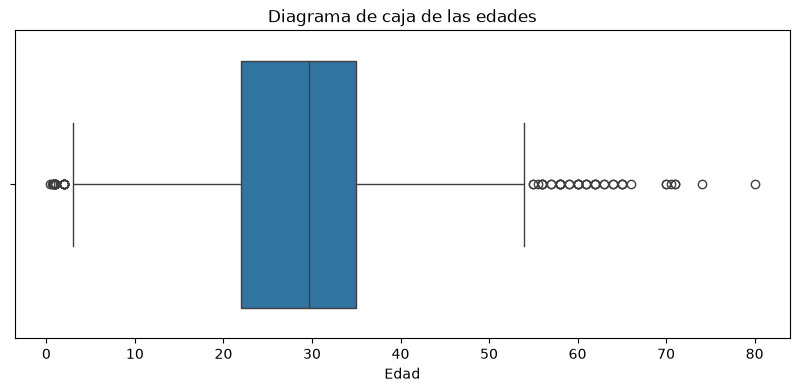

In [16]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="Age"
)

plt.title("Diagrama de caja de las edades")
plt.xlabel("Edad")
plt.show()

In [17]:
tarifa_minima = df["Fare"].min()
tarifa_maxima = df["Fare"].max()

print(f"Tarifa mínima: ${tarifa_minima:.2f}")
print(f"Tarifa máxima: ${tarifa_maxima:.2f}")

Tarifa mínima: $0.00
Tarifa máxima: $512.33


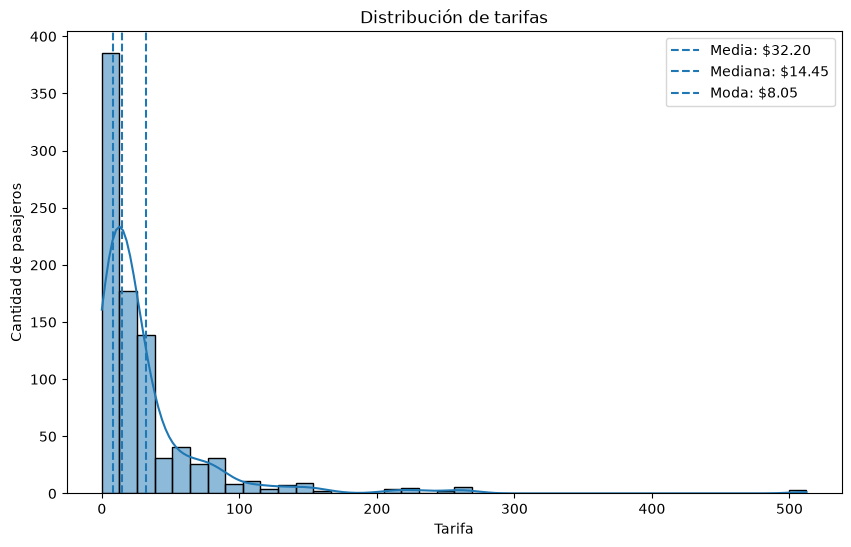

Media: $32.20
Mediana: $14.45
Moda: $8.05


In [18]:
media_tarifa = df["Fare"].mean()
mediana_tarifa = df["Fare"].median()
moda_tarifa = df["Fare"].mode()[0]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Fare",
    bins=40,
    kde=True
)

plt.axvline(
    media_tarifa,
    linestyle="--",
    label=f"Media: ${media_tarifa:.2f}"
)

plt.axvline(
    mediana_tarifa,
    linestyle="--",
    label=f"Mediana: ${mediana_tarifa:.2f}"
)

plt.axvline(
    moda_tarifa,
    linestyle="--",
    label=f"Moda: ${moda_tarifa:.2f}"
)

plt.title("Distribución de tarifas")
plt.xlabel("Tarifa")
plt.ylabel("Cantidad de pasajeros")
plt.legend()
plt.show()

print(f"Media: ${media_tarifa:.2f}")
print(f"Mediana: ${mediana_tarifa:.2f}")
print(f"Moda: ${moda_tarifa:.2f}")

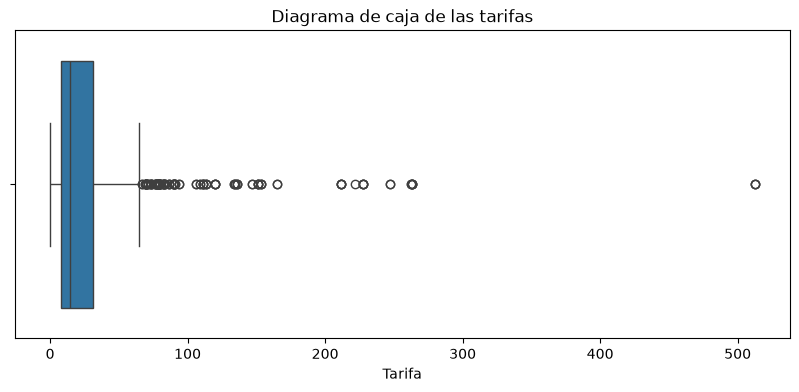

In [19]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="Fare"
)

plt.title("Diagrama de caja de las tarifas")
plt.xlabel("Tarifa")
plt.show()

In [20]:
pasajeros_tarifa_cero = df[df["Fare"] == 0]

print(
    f"Pasajeros que pagaron tarifa cero: "
    f"{len(pasajeros_tarifa_cero)}"
)

pasajeros_tarifa_cero

Pasajeros que pagaron tarifa cero: 15


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,GrupoEdad
179,0,3,male,36.000000,0,0,0.0,S,Adulto
263,0,1,male,40.000000,0,0,0.0,S,Adulto
271,1,3,male,25.000000,0,0,0.0,S,Joven Adulto
277,0,2,male,29.699118,0,0,0.0,S,Joven Adulto
302,0,3,male,19.000000,0,0,0.0,S,Joven Adulto
413,0,2,male,29.699118,0,0,0.0,S,Joven Adulto
466,0,2,male,29.699118,0,0,0.0,S,Joven Adulto
481,0,2,male,29.699118,0,0,0.0,S,Joven Adulto
597,0,3,male,49.000000,0,0,0.0,S,Adulto
633,0,1,male,29.699118,0,0,0.0,S,Joven Adulto


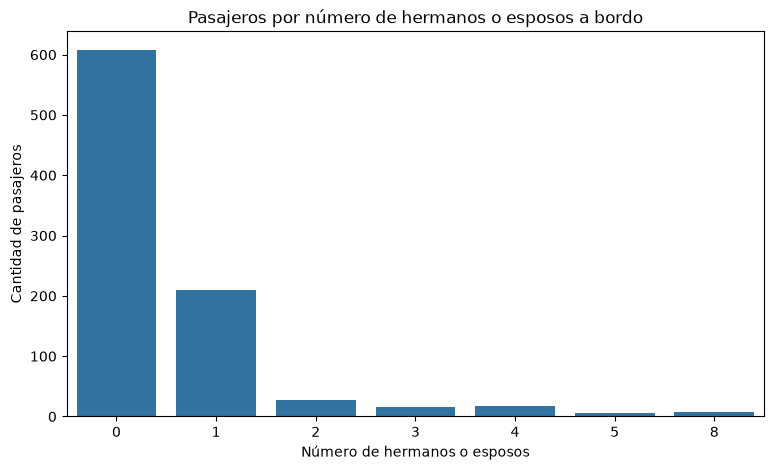

In [21]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="SibSp"
)

plt.title("Pasajeros por número de hermanos o esposos a bordo")
plt.xlabel("Número de hermanos o esposos")
plt.ylabel("Cantidad de pasajeros")
plt.show()

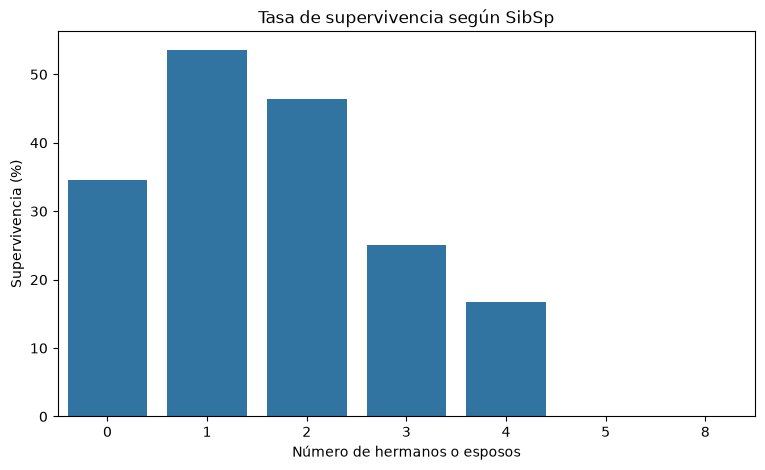

In [22]:
supervivencia_sibsp = (
    df.groupby("SibSp")["Survived"]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=supervivencia_sibsp,
    x="SibSp",
    y="Survived"
)

plt.title("Tasa de supervivencia según SibSp")
plt.xlabel("Número de hermanos o esposos")
plt.ylabel("Supervivencia (%)")
plt.show()

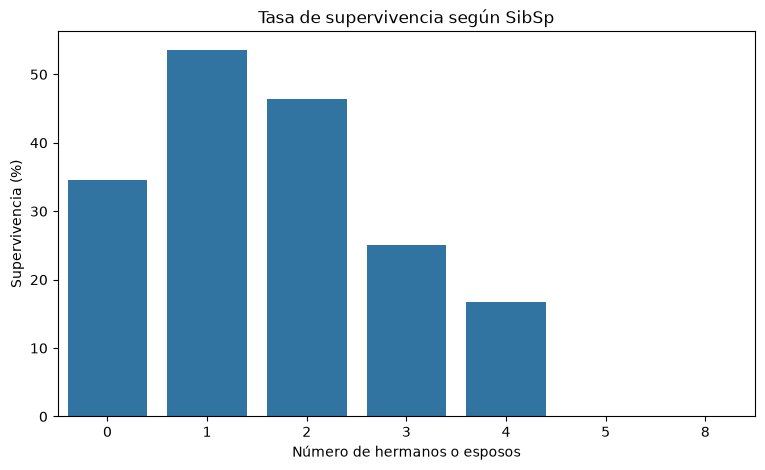

In [23]:
supervivencia_sibsp = (
    df.groupby("SibSp")["Survived"]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=supervivencia_sibsp,
    x="SibSp",
    y="Survived"
)

plt.title("Tasa de supervivencia según SibSp")
plt.xlabel("Número de hermanos o esposos")
plt.ylabel("Supervivencia (%)")
plt.show()

In [24]:
tabla_sibsp = (
    df.groupby("SibSp")["Survived"]
    .agg(
        Pasajeros="count",
        Sobrevivientes="sum",
        Tasa_supervivencia="mean"
    )
)

tabla_sibsp["Tasa_supervivencia"] = (
    tabla_sibsp["Tasa_supervivencia"] * 100
).round(2)

tabla_sibsp

,Pasajeros,Sobrevivientes,Tasa_supervivencia
SibSp,,,
0,608,210,34.54
1,209,112,53.59
2,28,13,46.43
3,16,4,25.00
4,18,3,16.67
5,5,0,0.00
8,7,0,0.00


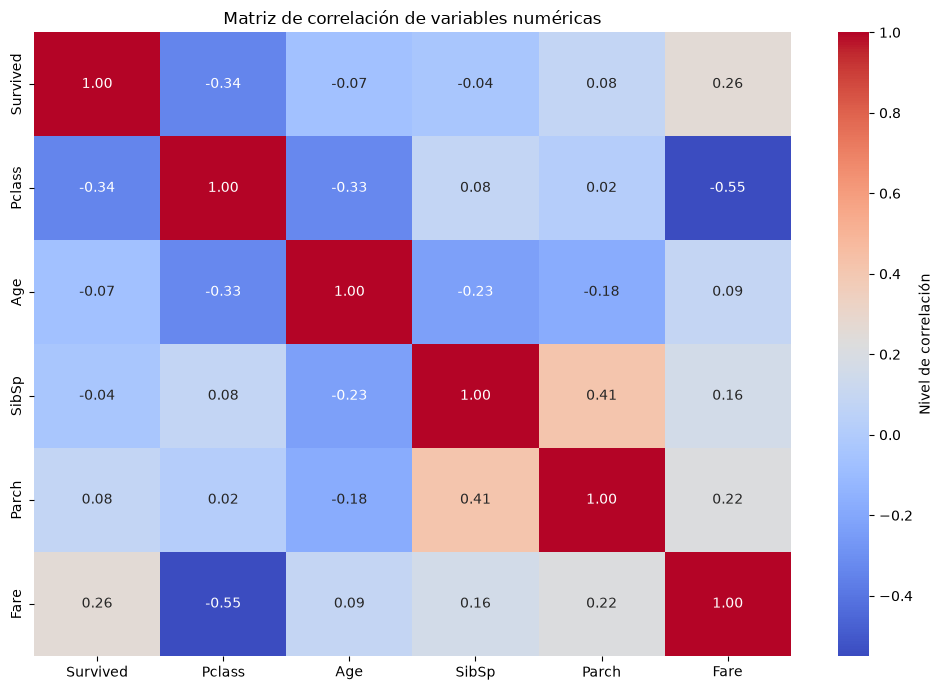

In [25]:
columnas_numericas = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

matriz_correlacion = df[columnas_numericas].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    cbar_kws={"label": "Nivel de correlación"}
)

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()